<a href="https://colab.research.google.com/github/stasy-af/pets/blob/main/recsys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np


In [37]:
sessions = []
with open("/content/drive/MyDrive/sessions.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            sessions.append(json.loads(line))

# sessions — список списков целых чисел
print(f"Всего сессий: {len(sessions)}")
print(f"Первая сессия: {sessions[0]}")

Всего сессий: 2565
Первая сессия: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]


#*analysis*

In [38]:
df = pd.DataFrame(data=sessions)
total = len(df) # number of sessions
uniq = df.stack().nunique() # number of unique products
lengths = [len(x) for x in sessions] # array of lengths of each session
all_vals = df.values.flatten()
all_vals = all_vals[~pd.isnull(all_vals)]
freq = pd.Series(all_vals).value_counts().reset_index() #series without NaN

freq.columns = ['variant', 'frequency']
freq['relative frequency'] = freq['frequency'] / freq['frequency'].sum() # relative freq col

freq = freq.sort_values('frequency', ascending=False)
freq['cum_share'] = freq['frequency'].cumsum() / freq['frequency'].sum() # % of most common products

print(f'unique products: {uniq}')
print(f'min length: {min(lengths)}')
print(f'avg length: {np.mean(lengths):.2f}')
print(f'median length: {np.median(lengths)}')
print(f'max length: {max(lengths)}')

unique products: 400
min length: 3
avg length: 10.47
median length: 9.0
max length: 20


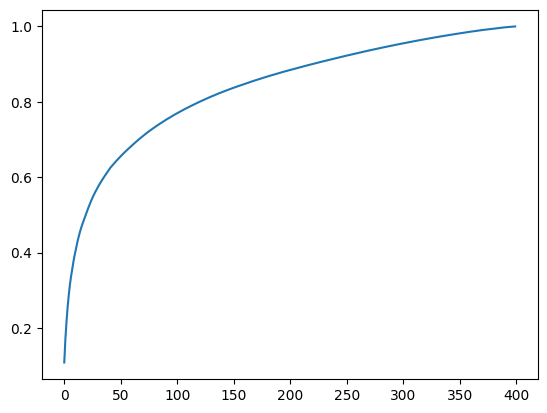

In [39]:
plt.plot(freq['cum_share'].values)
plt.show()

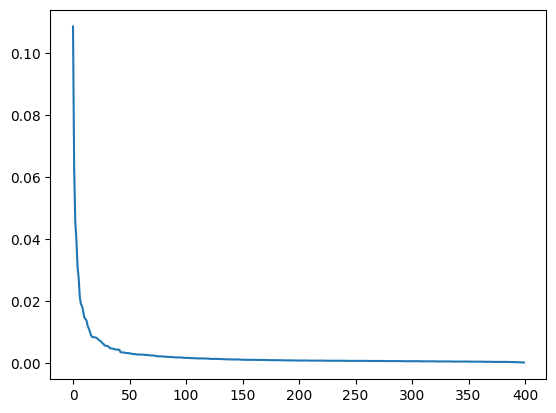

In [40]:
plt.plot(freq['relative frequency'].values)
plt.show()

In [41]:
repeat_rate = []
same_next = 0
all_pairs = 0

for session in sessions:
  repeat_rate.append(1 - len(set(session)) / len(session))
  for i in range(len(session) - 1):
    all_pairs += 1
    if session[i] == session[i + 1]:
      same_next += 1

print(f'mean repeat rate: {np.mean(repeat_rate)}')
print(f'same next rate: {same_next / all_pairs}')


mean repeat rate: 0.11168649488453772
same next rate: 0.0


Основываясь на первичном анализе предоставленных данных, можно сделать следующие выводы:

1.   распределение популярности товаров имеет выраженную ассиметрию с длинным хвостом с правой стороны.
2.   среди данных нет такой пары, где есть повтор в выборе (item1 -> item1)
3. повторные просмоторы товаров внутри одной сесси встречаются редко.




# train&test split

In [42]:
training = []
targets = []

for session in sessions:
  hist = session[:-1]
  target = session[-1]

  training.append(hist)
  targets.append(target)


# transition matrix

In [43]:
transitions = defaultdict(lambda: defaultdict(int))
for hist in training:
  for i in range(len(hist) - 1):
    curr_item = hist[i]
    next_item = hist[i + 1]

    transitions[curr_item][next_item] += 1

In [44]:
last_items = [session[-2] for session in sessions]
covered = sum(item in transitions for item in last_items)
print(covered / len(last_items))

1.0


# recsys

In [45]:
popularity = Counter()

for hist in training:
  for item in hist:
    popularity[item] += 1

top = [item for item, cnt in popularity.most_common(10)]
top

[54, 335, 53, 114, 260, 293, 380, 212, 329, 257]

In [46]:
def recommend(hist, transitions, top, k=10):
  last_item = hist[-1]
  recs = []
  if last_item in transitions:
    ranked = sorted(
        transitions[last_item].items(),
        key=lambda x: x[1],
        reverse=True
    )
    recs = [
        item for item, count in ranked if item != last_item
    ]
  for item in top:
    if item not in recs and item != last_item:
      recs.append(item)
  return recs[:k]

In [47]:
recommend(training[0], transitions, top)

[92, 149, 54, 287, 7, 212, 12, 260, 380, 335]

# inspection

In [48]:
hit_10 = 0
hit_p = 0
total = 0
for history, true_item in zip(training, targets):
  predicts = recommend(
      history, transitions, top, k=10
  )

  if true_item in predicts:
    hit_10 += 1
  total += 1
for target in targets:
  if target in top:
    hit_p += 1
pop_hit = hit_p / len(targets)
hit10 = hit_10 / total
print(f'hit@10: {hit10}')
print(f'baseline for 10: {pop_hit}')

hit@10: 0.5142300194931774
baseline for 10: 0.3840155945419103


Показатель hit@10 выше популярностного бейзлайна, что говрит о наличии последовательных паттернов в сессиях. Наиболее информативным признаком оказался последний просмотренный товар.